### Imports necesarios para el EDA

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from scipy.stats import chi2_contingency
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
from dotenv import load_dotenv

### Conexión a la BBDD
 

In [2]:
load_dotenv()
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_HOST = os.getenv("MYSQL_HOST")
MYSQL_PORT = os.getenv("MYSQL_PORT")
MYSQL_USER = os.getenv("MYSQL_USER")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")


# Crear motor de conexión
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
)

### Carga del dataset de la tabla RRHH

In [3]:
with engine.connect() :
    query = "SELECT * FROM RRHH;"
    df = pd.read_sql(query, engine)

### Dimensiones del dataset

In [4]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 740
Columnas: 21


### Muestra del dataset

In [5]:
# Muestra de las cinco primeras filas del DataFrame
df.head()

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",...,0,1,2,0,0,1,65,172,22,112


In [6]:
# Muestra de cinco filas aleatorias del DataFrame
df.sample(5, random_state=42)

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
120,23,19,4,4,3,378,49,11,36,"326,452",...,0,1,2,0,1,4,65,174,21,8
416,3,27,1,4,2,179,51,18,38,"313,532",...,0,1,0,1,0,0,89,170,31,3
334,3,10,3,2,2,179,51,18,38,"222,196",...,0,1,0,1,0,0,89,170,31,4
350,20,28,10,6,4,260,50,11,36,"253,465",...,0,1,4,1,0,0,65,168,23,3
412,28,23,12,4,4,225,26,9,28,"280,549",...,0,1,1,0,0,2,69,169,24,3


### Tipos de datos

In [7]:
tipos_datos = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "valores_unicos": df.nunique(),
    "valores_no_nulos": df.notna().sum(),
    "valores_nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2)
}).reset_index().rename(columns={"index": "columna"})

tipos_datos

,columna,tipo_dato,valores_unicos,valores_no_nulos,valores_nulos,porcentaje_nulos
0,ID,int64,36,740,0,0.0
1,Reason_absence,int64,28,740,0,0.0
2,Month_absence,int64,13,740,0,0.0
3,Day_week,int64,5,740,0,0.0
4,Seasons,int64,4,740,0,0.0
5,Transportation_expense,int64,24,740,0,0.0
6,Distance_Residence_Work,int64,25,740,0,0.0
7,Service_time,int64,18,740,0,0.0
8,Age,int64,22,740,0,0.0
9,Work_load_Average_day,str,38,740,0,0.0


### Duplicados

In [8]:
duplicados_detalle = df[df.duplicated(keep=False)].sort_values(list(df.columns))
print(f"Registros involucrados en duplicados completos: {len(duplicados_detalle)}")
duplicados_detalle.head(10)

Registros involucrados en duplicados completos: 60


,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
453,3,23,7,6,1,179,51,18,38,"239,554",...,0,1,0,1,0,0,89,170,31,2
454,3,23,7,6,1,179,51,18,38,"239,554",...,0,1,0,1,0,0,89,170,31,2
558,3,27,2,2,2,179,51,18,38,"264,249",...,0,1,0,1,0,0,89,170,31,2
564,3,27,2,2,2,179,51,18,38,"264,249",...,0,1,0,1,0,0,89,170,31,2
379,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
383,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
386,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
388,3,27,2,4,2,179,51,18,38,"251,818",...,0,1,0,1,0,0,89,170,31,3
552,3,27,2,4,2,179,51,18,38,"264,249",...,0,1,0,1,0,0,89,170,31,2
562,3,27,2,4,2,179,51,18,38,"264,249",...,0,1,0,1,0,0,89,170,31,2


In [9]:
duplicados = df.duplicated().sum()

print(f"Filas duplicadas: {duplicados}")
print(f"Porcentaje duplicado: {duplicados / len(df) * 100:.2f}%")


Filas duplicadas: 34
Porcentaje duplicado: 4.59%


### Clasificación de variables en categórica y númericas ( discretas y continuas )

In [10]:
variables_categoricas = [
    'Reason_absence', 'Month_absence', 'Day_week', 'Seasons', 'Education'
]

variables_booleanas = ['Disciplinary_failure', 'Social_drinker', 'Social_smoker']

variables_discretas = ['Son', 'Pet' ]

variables_continuas = [
    'Transportation_expense', 'Distance_Residence_Work', 'Work_load_Average_day', 'Age', 
    'Hit_target', 'Weight', 'Height', 'Body_mass_index', 'Absenteeism_hours', 'Service_time'
]


### Conversiones de datos para facilitar el EDA

In [11]:
# Convertir las columnas "Son" y "Pet" a tipo int para que puedan ser utilizadas como numéricas.

df['Son'] = df['Son'].astype(int)
df['Pet'] = df['Pet'].astype(int)


# Convertir la columna "Work_load_Average_day" a tipo float para que pueda ser utilizada como númerica.

df["Work_load_Average_day"] = (
    df["Work_load_Average_day"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Convertir las columnas categóricas a tipo "category".

for col in variables_categoricas:
    df[col] = df[col].astype("category")

### Analisis Estadístico 

#### Variables númericas

In [12]:
variables_numericas = variables_discretas + variables_continuas

df[variables_numericas].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Son,740.0,1.02,1.10,0.00,0.00,1.00,2.00,4.00
Pet,740.0,0.75,1.32,0.00,0.00,0.00,1.00,8.00
Transportation_expense,740.0,221.33,66.95,118.00,179.00,225.00,260.00,388.00
Distance_Residence_Work,740.0,29.63,14.84,5.00,16.00,26.00,50.00,52.00
Work_load_Average_day,740.0,271.49,39.06,205.92,244.39,264.25,294.22,378.88
Age,740.0,36.45,6.48,27.00,31.00,37.00,40.00,58.00
Hit_target,740.0,94.59,3.78,81.00,93.00,95.00,97.00,100.00
Weight,740.0,79.04,12.88,56.00,69.00,83.00,89.00,108.00
Height,740.0,172.11,6.03,163.00,169.00,170.00,172.00,196.00
Body_mass_index,740.0,26.68,4.29,19.00,24.00,25.00,31.00,38.00


#### Variables categóricas

In [13]:
df[variables_categoricas+variables_booleanas].describe().T

,count,unique,top,freq
Reason_absence,740,28,23,149
Month_absence,740,13,3,87
Day_week,740,5,2,161
Seasons,740,4,4,195
Education,740,4,1,611
Disciplinary_failure,740,2,0,700
Social_drinker,740,2,1,420
Social_smoker,740,2,0,686


### Visualizaciones

In [14]:
sns.set_theme(style="whitegrid")

#### Distribución Numéricas Continuas

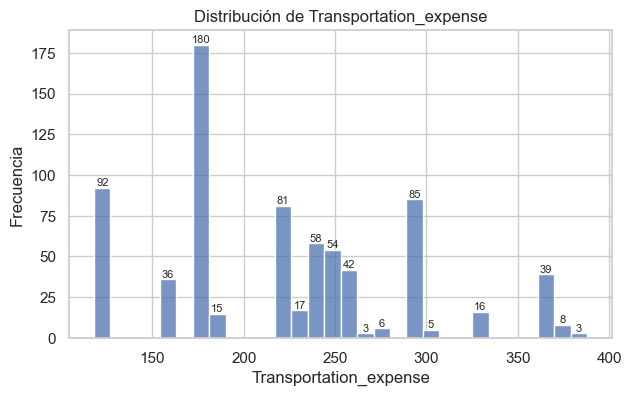

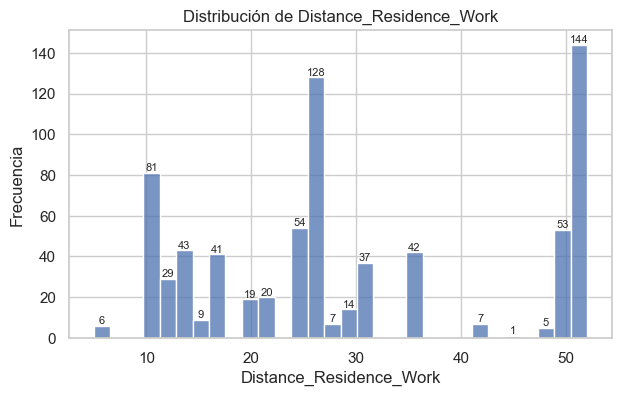

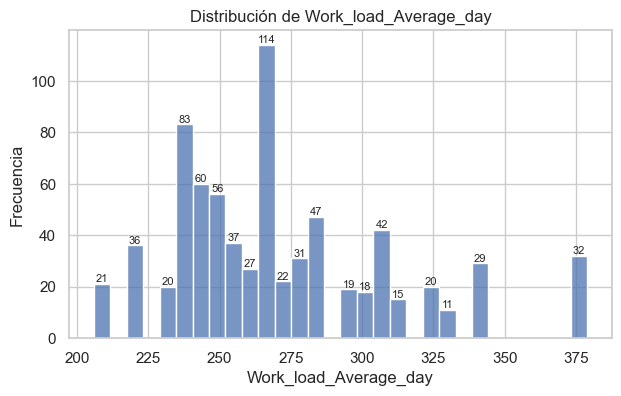

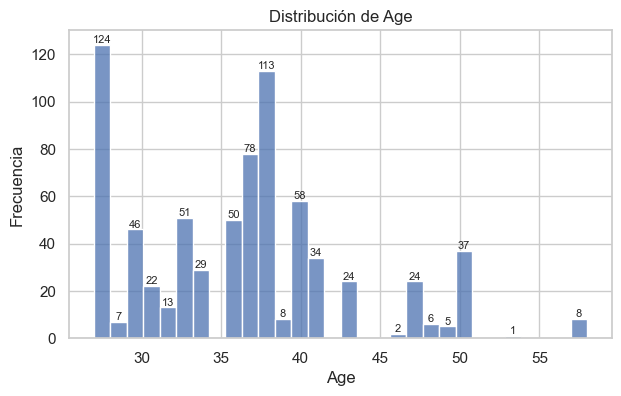

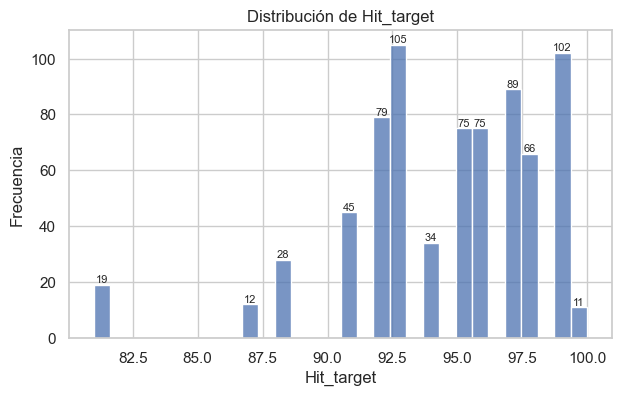

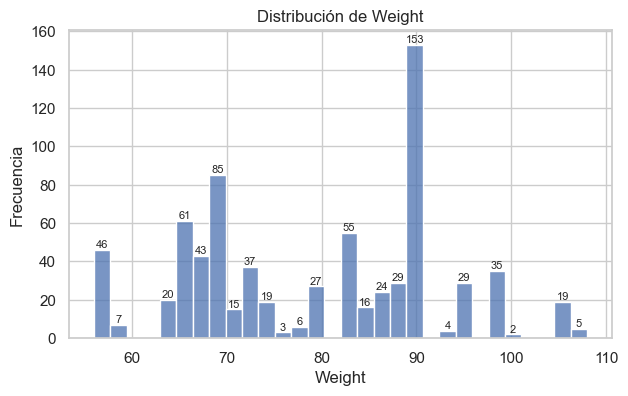

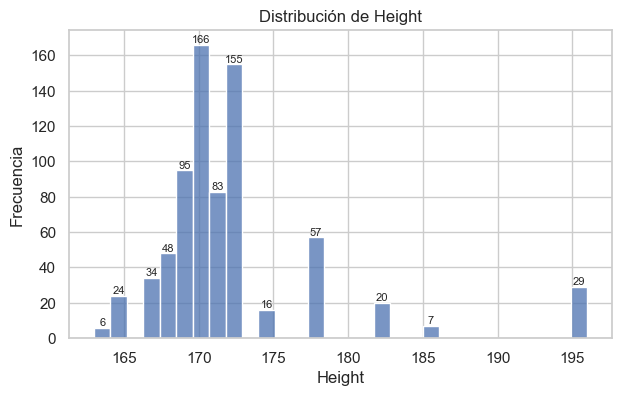

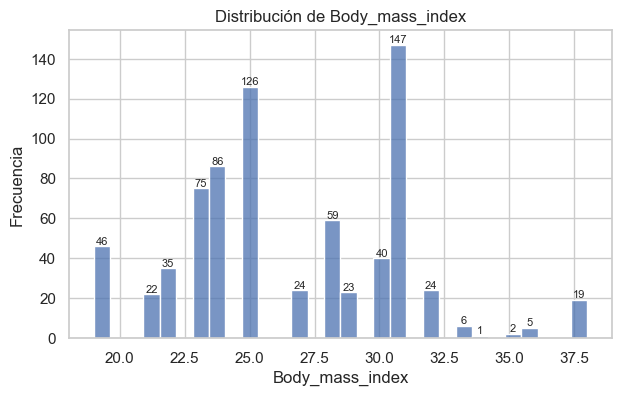

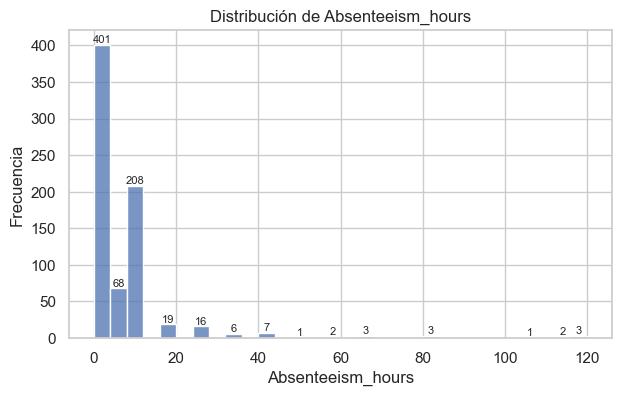

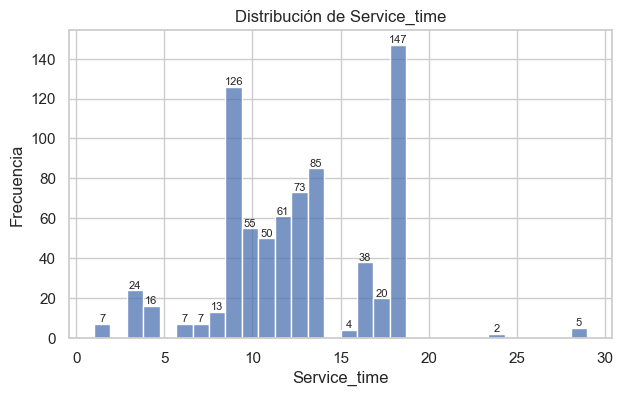

In [15]:
for col in variables_continuas:
    plt.figure(figsize=(7, 4))
    ax =sns.histplot(data=df, x=col, bins=30)

    for p in ax.patches:
        altura = int(p.get_height())
        if altura > 0:
            ax.text(
                p.get_x() + p.get_width() / 2,
                altura,
                str(altura),
                ha="center",
                va="bottom",
                fontsize=8
            )

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

#### Distribución númericas discretas

,Son,frecuencia,porcentaje
0,0,298,40.27
1,1,229,30.95
2,2,156,21.08
3,3,15,2.03
4,4,42,5.68


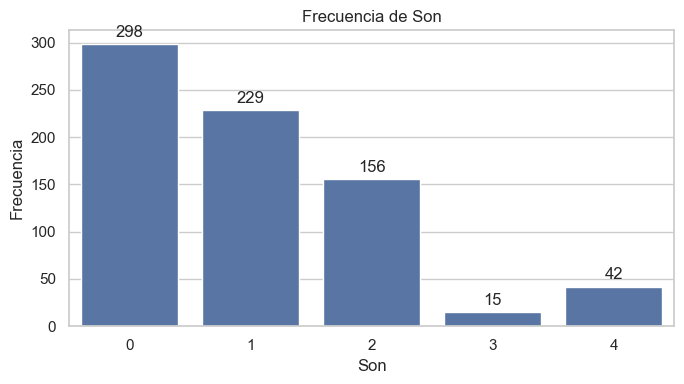

,Pet,frecuencia,porcentaje
0,0,460,62.16
1,1,138,18.65
2,2,96,12.97
3,4,32,4.32
4,5,6,0.81
5,8,8,1.08


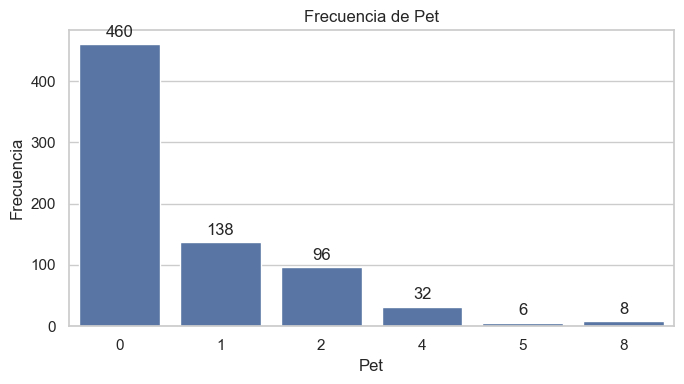

In [16]:
for col in variables_discretas:
    tabla_frecuencia = (
        df[col]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis(col)
        .reset_index(name="frecuencia")
    )
    
    tabla_frecuencia["porcentaje"] = (
        tabla_frecuencia["frecuencia"] / len(df) * 100
    ).round(2)
    
    display(tabla_frecuencia)
    
    plt.figure(figsize=(7, 4))
    ax = sns.barplot(data=tabla_frecuencia, x=col, y="frecuencia")
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)

    plt.title(f"Frecuencia de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

#### Detección de Outliers (continuas)

##### Resumen cuantitativo de outliers

In [17]:
resumen_outliers = []

for col in variables_continuas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mascara = (df[col] < limite_inferior) | (df[col] > limite_superior)

    resumen_outliers.append({
        "variable": col,
        "limite_inferior": round(limite_inferior, 2),
        "limite_superior": round(limite_superior, 2),
        "n_outliers": int(mascara.sum()),
        "porcentaje_outliers": round(mascara.mean() * 100, 2),
        "min": df[col].min(),
        "max": df[col].max()
    })

resumen_outliers = pd.DataFrame(resumen_outliers).sort_values("porcentaje_outliers", ascending=False)
resumen_outliers


,variable,limite_inferior,limite_superior,n_outliers,porcentaje_outliers,min,max
6,Height,164.50,176.50,119,16.08,163.000,196.000
8,Absenteeism_hours,-7.00,17.00,44,5.95,0.000,120.000
2,Work_load_Average_day,169.64,368.96,32,4.32,205.917,378.884
4,Hit_target,87.00,103.00,19,2.57,81.000,100.000
3,Age,17.50,53.50,8,1.08,27.000,58.000
9,Service_time,-1.50,26.50,5,0.68,1.000,29.000
0,Transportation_expense,57.50,381.50,3,0.41,118.000,388.000
1,Distance_Residence_Work,-35.00,101.00,0,0.00,5.000,52.000
5,Weight,39.00,119.00,0,0.00,56.000,108.000
7,Body_mass_index,13.50,41.50,0,0.00,19.000,38.000


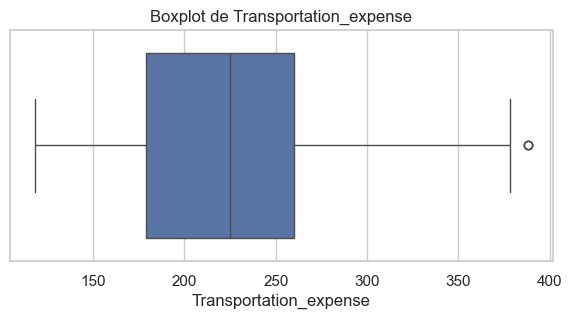

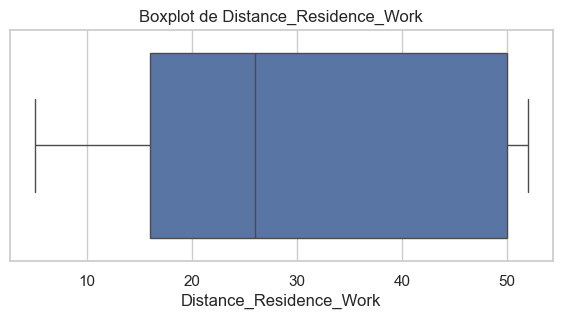

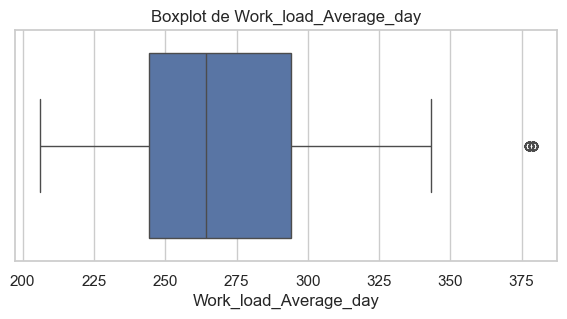

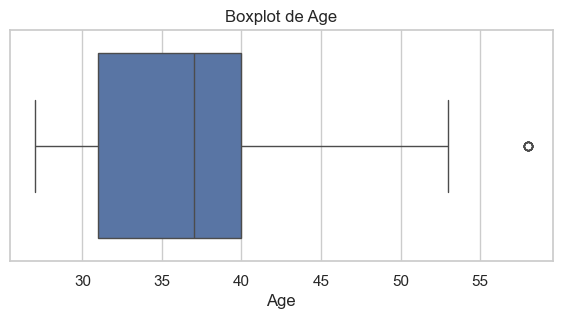

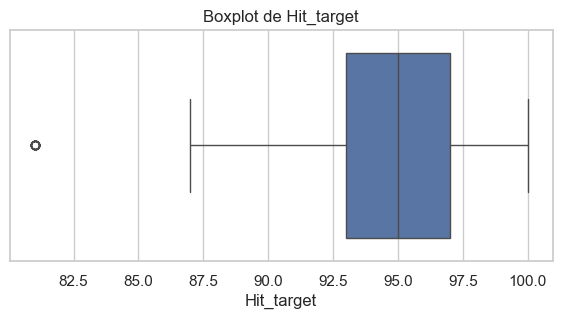

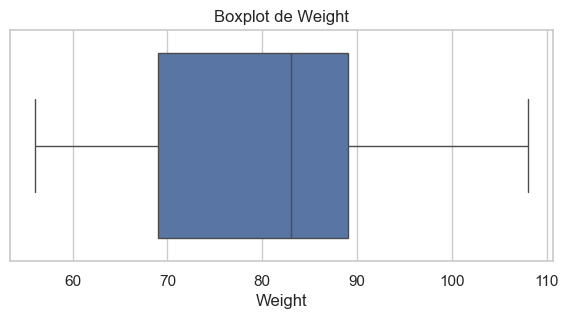

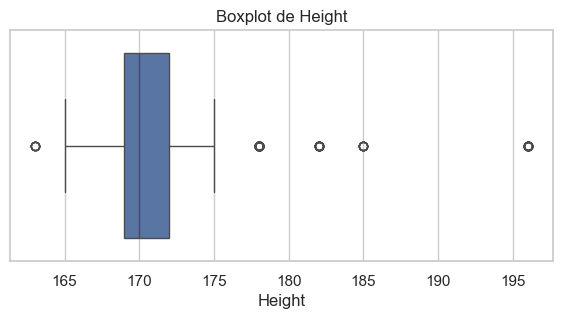

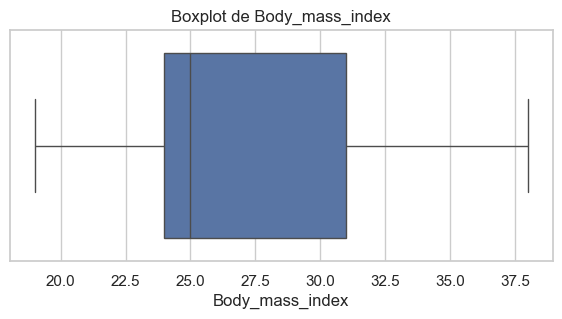

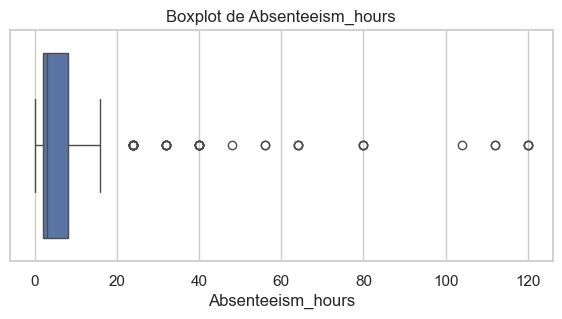

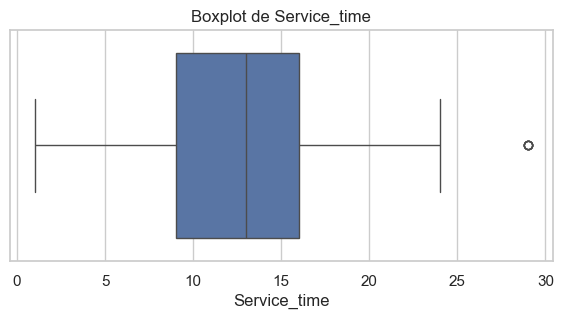

In [18]:
for col in variables_continuas:
    plt.figure(figsize=(7, 3))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

#### Frecuencias Categóricas

In [19]:
ordenes_categoricas = {
    "Month_absence": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "Day_week": [2, 3, 4, 5, 6],
    "Seasons": [1, 2, 3, 4],
    "Education": [1, 2, 3, 4]

}

diccionario_categoricas = {
    "Month_absence": {
        0:"Sin mes",
        1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr",
        5: "May", 6: "Jun", 7: "Jul", 8: "Ago",
        9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
    },
    "Day_week": {
        2: "Lun", 3: "Mar", 4: "Mié", 5: "Jue", 6: "Vie"
    },
    "Seasons": {
        1: "Verano", 2: "Otoño", 3: "Invierno", 4: "Primavera"
    },
    "Education": {
        1: "Secundaria", 2: "Graduado", 3: "Postgrado", 4: "Master o doctorado"
    }

}

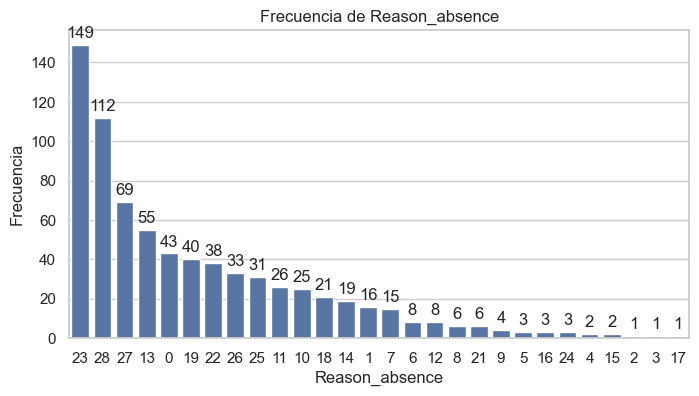

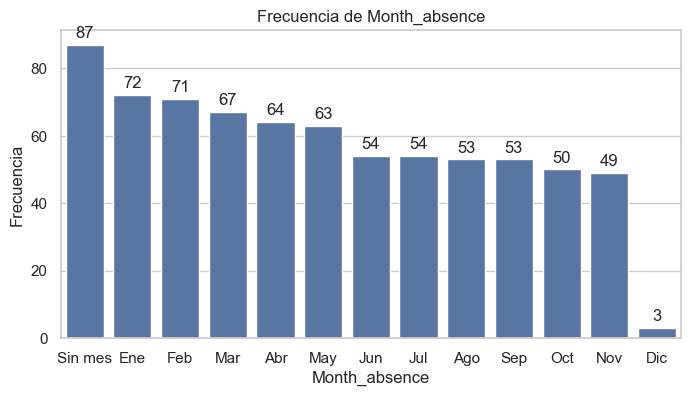

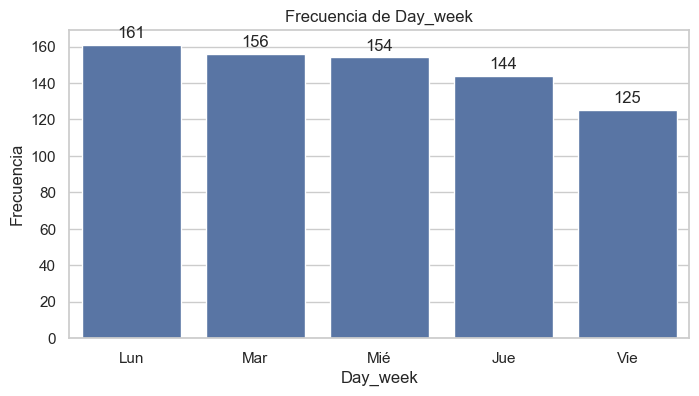

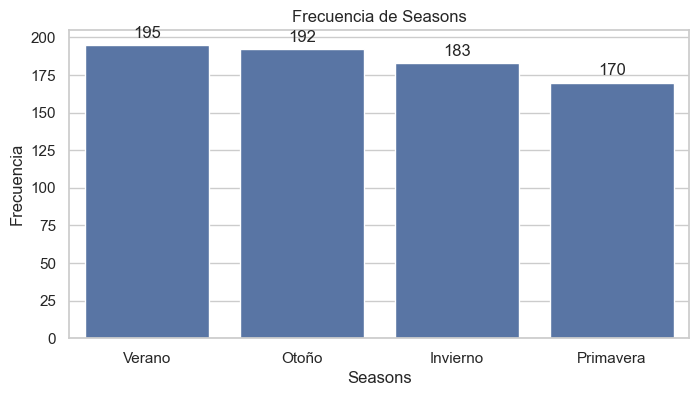

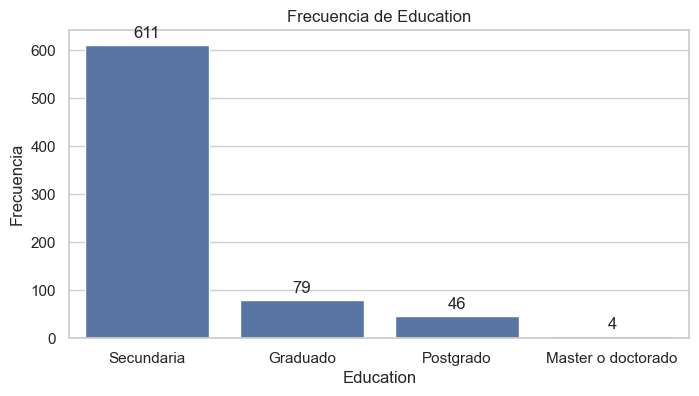

In [20]:
for col in variables_categoricas:
    plt.figure(figsize=(8, 4))
    orden = df[col].value_counts().index
    ax =sns.countplot(data=df, x=col, order=orden)
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)

    if col in diccionario_categoricas:
        labels = [diccionario_categoricas[col].get(x, x) for x in ordenes_categoricas[col]]
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels)

    plt.title(f"Frecuencia de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=0)
    plt.show()

#### Porcentaje Booleanas

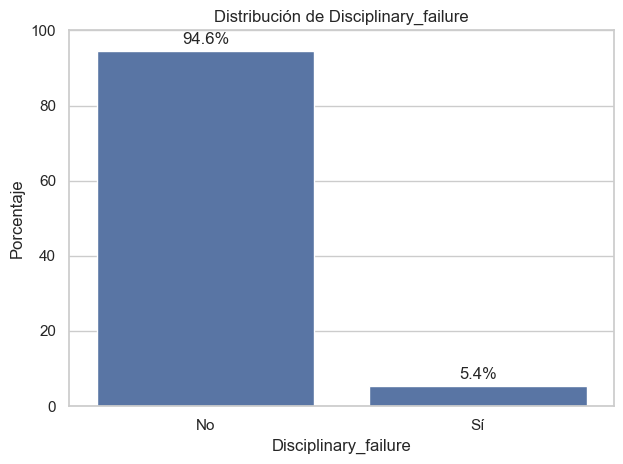

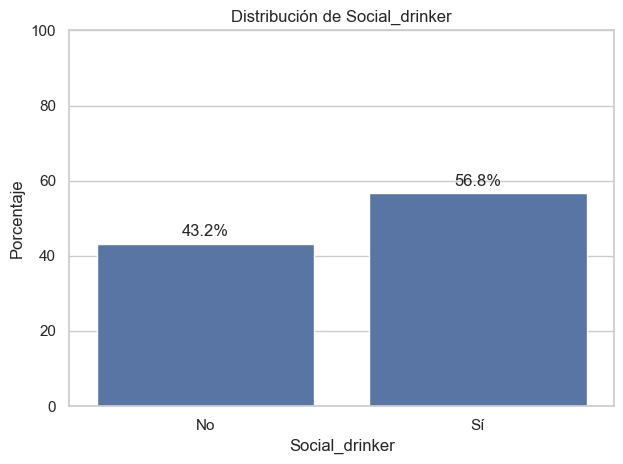

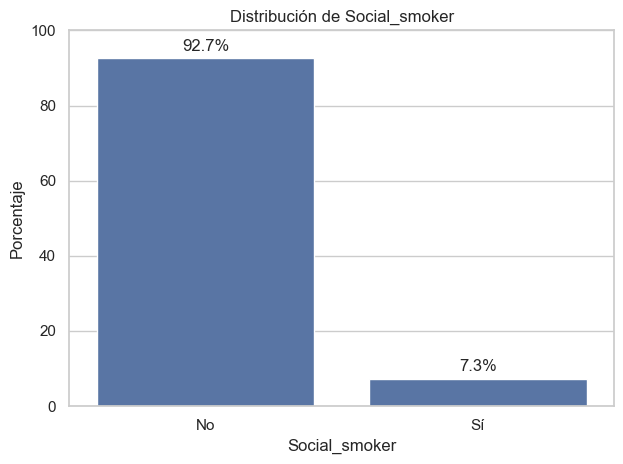

In [21]:
for col in variables_booleanas:
    serie = pd.to_numeric(df[col], errors="coerce")
    tabla = (
        serie
        .map({0: "No", 1: "Sí"})
        .value_counts(normalize=True)
        .mul(100)
        .reindex(["No", "Sí"])
        .reset_index()
    )

    tabla.columns = [col, "porcentaje"]

    ax = sns.barplot(data=tabla, x=col, y="porcentaje")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Porcentaje")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

#### Relaciones entre variables

##### Graficos de dispersión

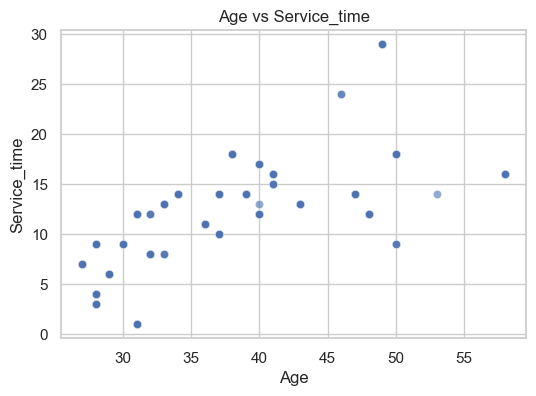

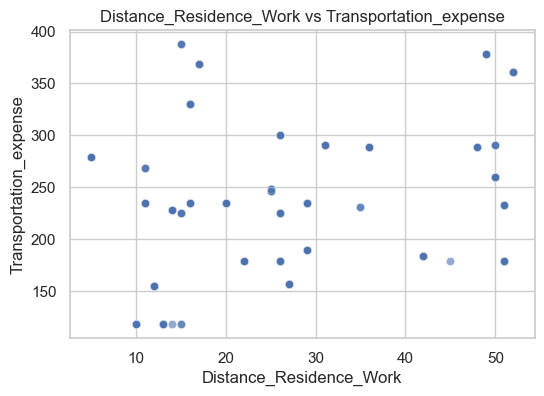

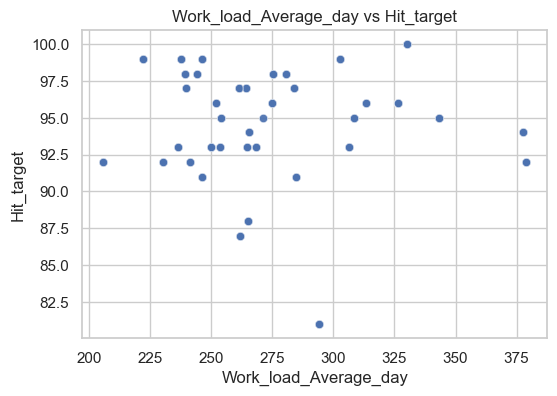

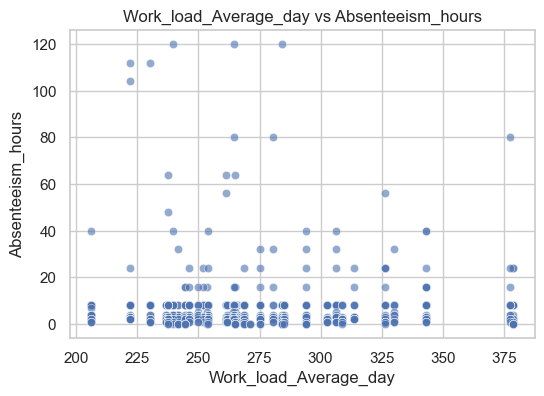

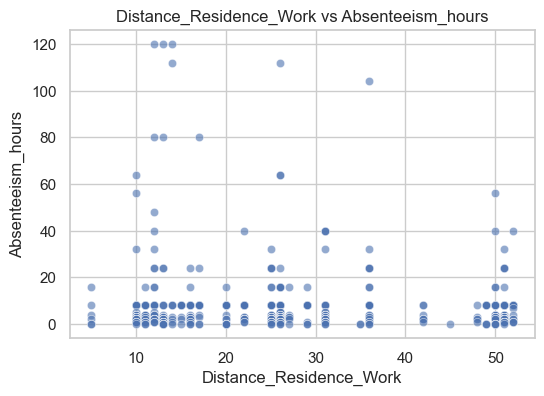

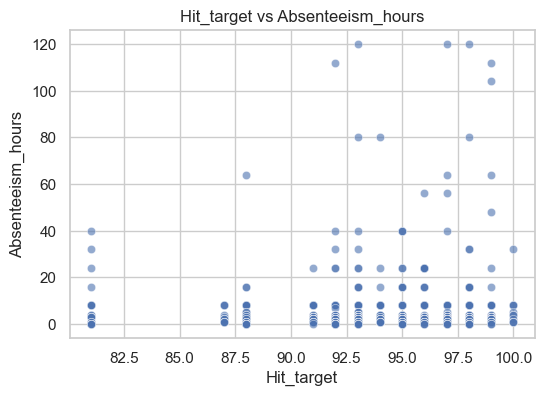

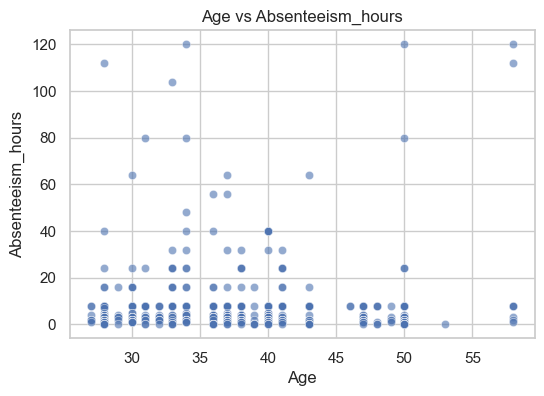

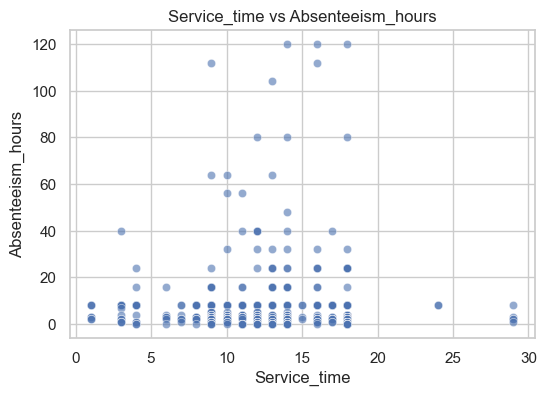

In [22]:
pares_dispersion = [
    ("Age", "Service_time"),
    ("Distance_Residence_Work", "Transportation_expense"),
    ("Work_load_Average_day", "Hit_target"),
    ("Work_load_Average_day", "Absenteeism_hours"),
    ("Distance_Residence_Work", "Absenteeism_hours"),
    ("Hit_target", "Absenteeism_hours"),
    ("Age", "Absenteeism_hours"),
    ("Service_time", "Absenteeism_hours")
]

for x, y in pares_dispersion:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=x, y=y, alpha=0.6)
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

##### Matriz de correlación

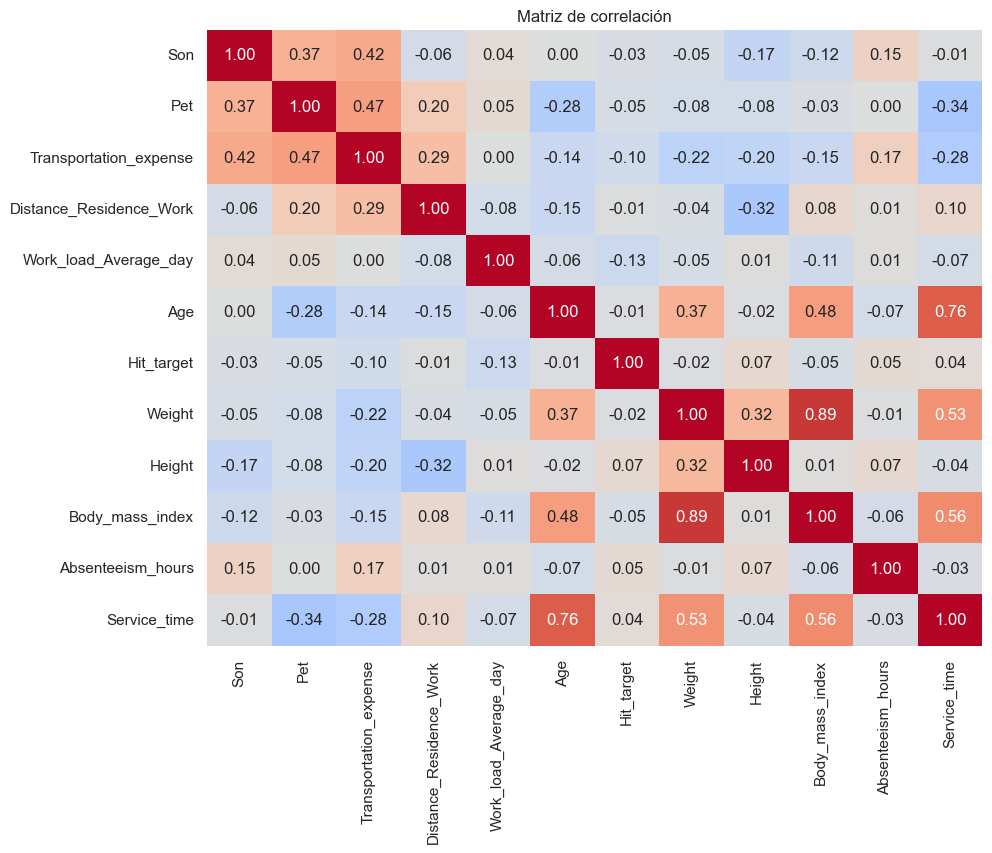

In [23]:
variables_correlacion = variables_discretas + variables_continuas

matriz_correlacion = df[variables_correlacion].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    cbar=False
)
plt.title("Matriz de correlación")
plt.show()

##### Cruce de categóricas


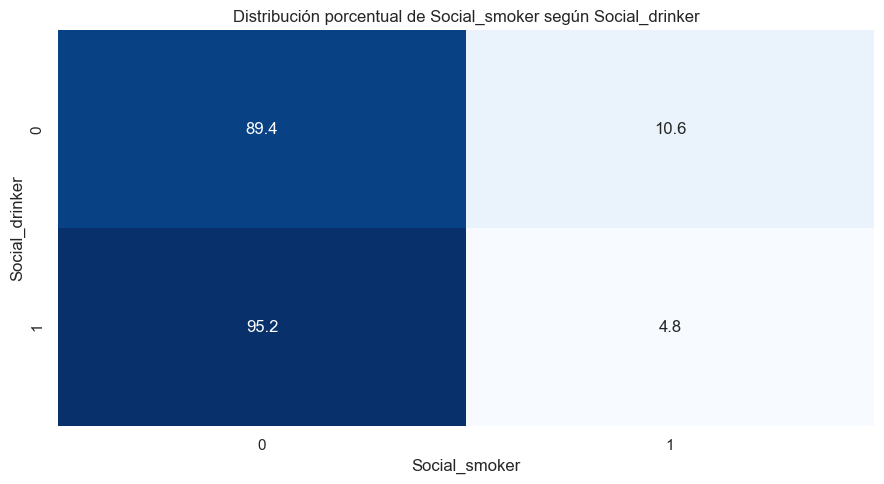

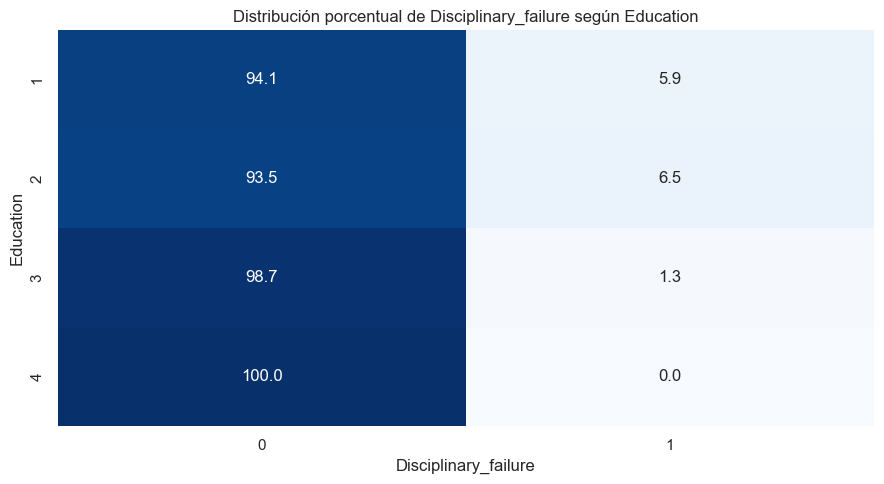

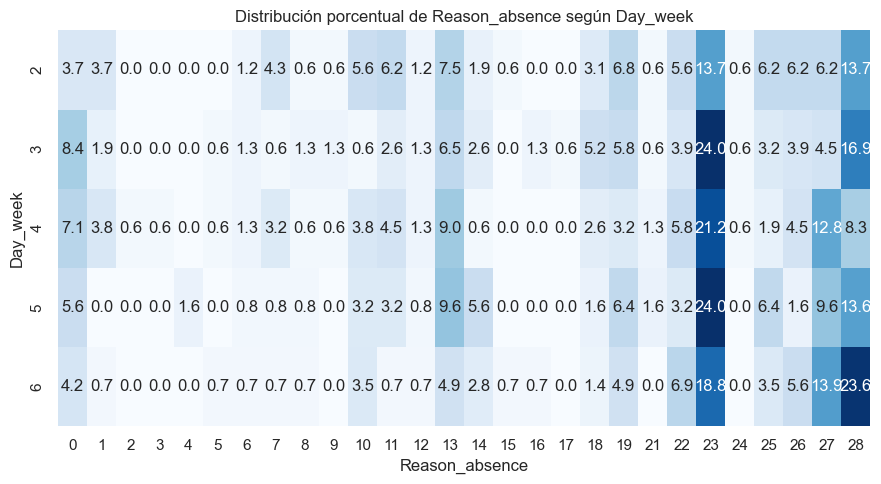

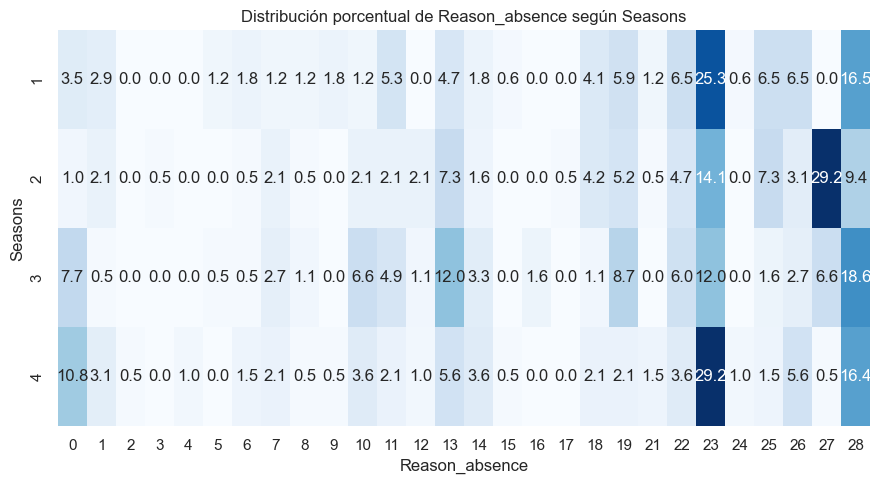

In [24]:
pares_categoricos = [
    ("Social_drinker", "Social_smoker"),
    ("Education", "Disciplinary_failure"),
    ("Day_week", "Reason_absence"),
    ("Seasons", "Reason_absence")
]

for col1, col2 in pares_categoricos:
    tabla_porcentaje = pd.crosstab(
        df[col1],
        df[col2],
        normalize="index"
    ) * 100

    plt.figure(figsize=(9, 5))
    sns.heatmap(
        tabla_porcentaje,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"Distribución porcentual de {col2} según {col1}")
    plt.xlabel(col2)
    plt.ylabel(col1)
    plt.tight_layout()
    plt.show()

In [25]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

asociaciones_categoricas = []

variables_asociaciones = variables_categoricas + variables_booleanas

for i, col1 in enumerate(variables_asociaciones):
    for col2 in variables_asociaciones[i+1:]:
        asociaciones_categoricas.append({
            "variable_1": col1,
            "variable_2": col2,
            "cramers_v": cramers_v(df[col1], df[col2])
        })

asociaciones_categoricas = pd.DataFrame(asociaciones_categoricas)

asociaciones_categoricas.sort_values("cramers_v", ascending=False)

,variable_1,variable_2,cramers_v
4,Reason_absence,Disciplinary_failure,0.962417
8,Month_absence,Seasons,0.903129
23,Education,Social_drinker,0.472039
24,Education,Social_smoker,0.364395
6,Reason_absence,Social_smoker,0.355753
2,Reason_absence,Seasons,0.347358
5,Reason_absence,Social_drinker,0.346043
3,Reason_absence,Education,0.291881
0,Reason_absence,Month_absence,0.259834
10,Month_absence,Disciplinary_failure,0.233899


##### Cruce categóricas, numéricas

,count,mean,median,std
Education,,,,
1,611,94.39,95.0,3.86
2,46,95.98,96.0,2.48
3,79,95.09,96.0,3.61
4,4,98.50,99.0,1.00


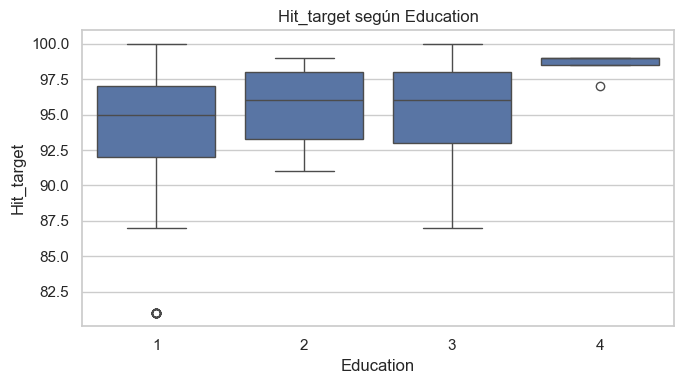

,count,mean,median,std
Education,,,,
1,611,13.06,13.0,4.17
2,46,9.46,6.0,6.87
3,79,10.33,9.0,2.39
4,4,15.00,15.0,0.00


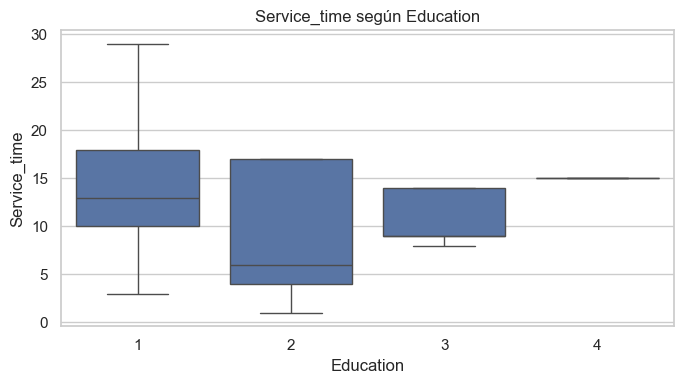

,count,mean,median,std
Education,,,,
1,611,7.19,3.0,14.26
2,46,6.39,8.0,6.75
3,79,5.27,3.0,7.96
4,4,5.25,5.5,3.20


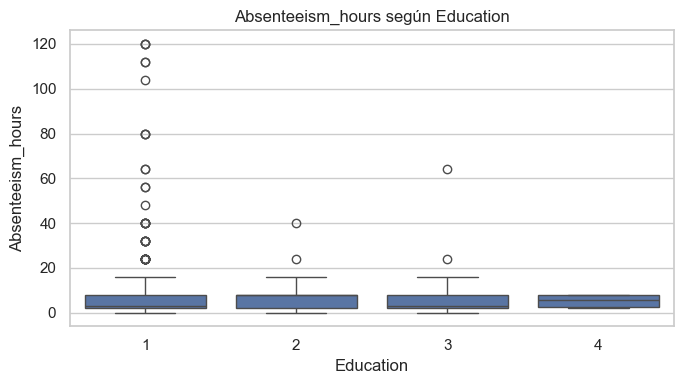

,count,mean,median,std
Disciplinary_failure,,,,
0,700,7.32,3.0,13.6
1,40,0.00,0.0,0.0


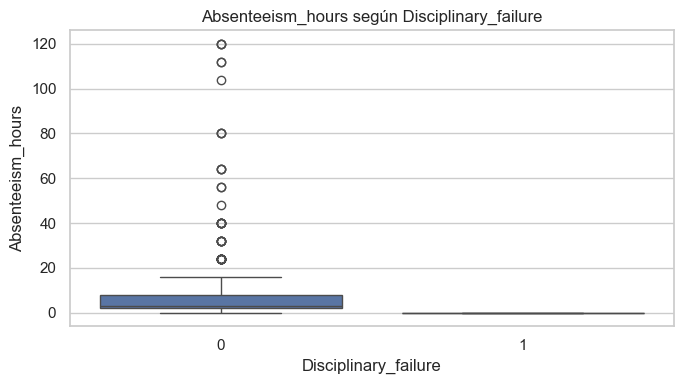

,count,mean,median,std
Disciplinary_failure,,,,
0,700,94.72,95.0,3.65
1,40,92.25,92.0,5.15


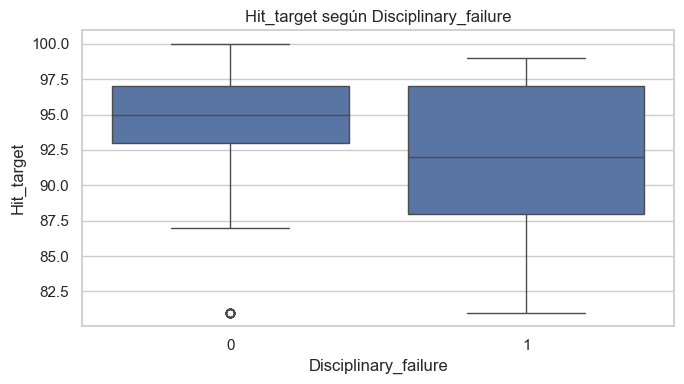

,count,mean,median,std
Social_drinker,,,,
0,320,25.09,24.0,4.06
1,420,27.89,28.0,4.06


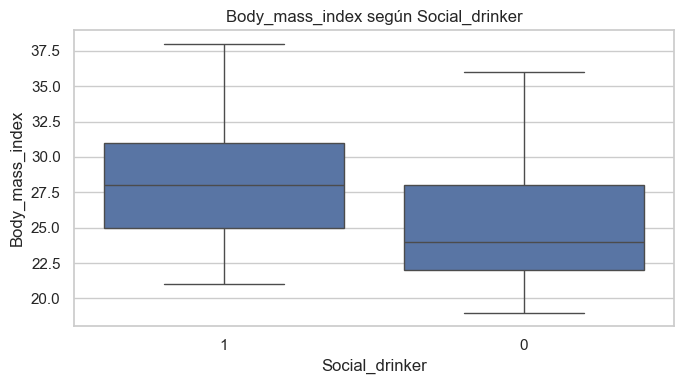

,count,mean,median,std
Social_smoker,,,,
0,686,6.96,3.0,13.56
1,54,6.50,3.5,10.09


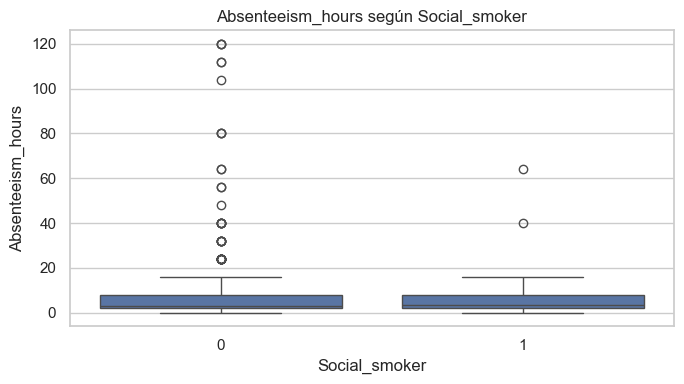

In [26]:
cruces = [
    ("Education", "Hit_target"),
    ("Education", "Service_time"),
    ("Education", "Absenteeism_hours"),
    ("Disciplinary_failure", "Absenteeism_hours"),
    ("Disciplinary_failure", "Hit_target"),
    ("Social_drinker", "Body_mass_index"),
    ("Social_smoker", "Absenteeism_hours")
]

for cat, num in cruces:
    display(
        df.groupby(cat)[num]
        .agg(["count", "mean", "median", "std"])
        .round(2)
    )

    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x=cat, y=num)
    plt.title(f"{num} según {cat}")
    plt.tight_layout()
    plt.show()

### Conclusiones

#### Conclusiones Generales

* Plantilla con edad media de 36.5 años. La mayoría está entre 31 y 40 años, así que es una plantilla relativamente adulta.
* Antigüedad media de 12.6 años, con mediana de 13. Esto sugiere una plantilla bastante estable.
* Distancia media al trabajo de 29.6 km, aunque el 75% está por debajo de 50 km. Hay bastante dispersión en desplazamiento.
* Gasto medio de transporte de 221.3, con valores entre 118 y 388. Puede reflejar diferencias relevantes en ubicación o medio de transporte.
* Rendimiento operativo alto: Hit_target tiene media 94.6, mediana 95 y el 75% está por debajo o igual a 97. En general, los objetivos se cumplen bastante bien.
* Carga diaria media de trabajo de 271.5, con variabilidad moderada. No parece extremadamente dispersa.
* En salud corporal, el IMC medio es 26.7, por encima del rango normal clásico. La mediana es 25 y el 75% llega a 31, lo que sugiere presencia relevante de sobrepeso.
* El absentismo es muy asimétrico: media 6.9 horas, mediana 3, pero máximo 120. La mayoría de ausencias son cortas, pero existen casos extremos que elevan mucho la media.
* En promedio tienen 1 hijo y la mayoría tiene entre 0 y 2 hijos.
* La variable Pet está muy concentrada en cero: mediana 0, aunque hay casos con hasta 8 mascotas.

* Motivo de ausencia más frecuente: Reason_absence = 23, con 149 registros. Según el diccionario, es consulta médica.
* Mes más frecuente: Month_absence = 3, con 87 registros. Marzo concentra más ausencias.
* Día más frecuente: Day_week = 2, con 161 registros. Según el diccionario, es lunes. Hay más registros de ausencia al inicio de la semana.
* Estación más frecuente: Seasons = 4, con 195 registros. Es primavera.
* Educación dominante: Education = 1, con 611 registros. La mayoría tiene educación secundaria/high school.
* Fallo disciplinario: Disciplinary_failure = 0, con 700 registros. La gran mayoría no tiene fallo disciplinario.
* Bebedor social: Social_drinker = 1, con 420 registros. Predominan los bebedores sociales.
* Fumador social: Social_smoker = 0, con 686 registros. La gran mayoría no fuma.



#### Conclusiones Relaciones

Correlaciones fuertes o relevantes
* Weight y Body_mass_index: 0.89
Normal dado que el IMC depende directamente del peso.

* Age y Service_time: 0.76
Empleados de mayor edad tienden a tener más tiempo de servicio.

    * Body_mass_index y Service_time: 0.56

    * Age y Body_mass_index: 0.48

    * Weight y Service_time: 0.53

* Son y Transportation_expense: 0.42
* Pet y Transportation_expense: 0.47
Empleado con hijos o mascotas tienden a gastar más en transporte.


Relaciones negativas
* Pet y Service_time: -0.34
Empleados con más tiempo de servicio tienden a tener menos mascotas. 
* Pet y Age: -0.28
Empleados con más edad tienden a tener menos mascotas. 

* Transportation_expense y Service_time: -0.28
A mayor tiempo de servicio, menor gasto de transporte. Podría deberse a perfiles de empleados, ubicación o antigüedad.


Cruces de categóricas

* Reason_absence vs Disciplinary_failure: 0.962
 Probablemente porque ciertos motivos de ausencia están directamente ligados a fallo disciplinario o ausencia injustificada. Revisaría la tabla cruzada: puede haber una categoría casi exclusiva.

* Education vs Social_drinker: 0.472
Asociación moderada. El consumo social de alcohol varía según nivel educativo.

* Education vs Social_smoker: 0.364
Asociación moderada-baja. El hábito de fumar también cambia según educación, aunque menos que beber.

Estas sugieren que los motivos de ausencia no se distribuyen igual según hábitos sociales o estación:
 
* Reason_absence vs Social_smoker: 0.356
* Reason_absence vs Seasons: 0.347
* Reason_absence vs Social_drinker: 0.346
